In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings("ignore")

In [15]:
df = pd.read_csv(r"C:\Users\admin\Downloads\Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
#inspect and clean data
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [17]:
df.columns = df.columns.str.strip()

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [20]:
df = df.dropna()

In [21]:
#exploration
df['Estimated Unemployment Rate (%)'].describe()

count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64

In [22]:
#national trend

national_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

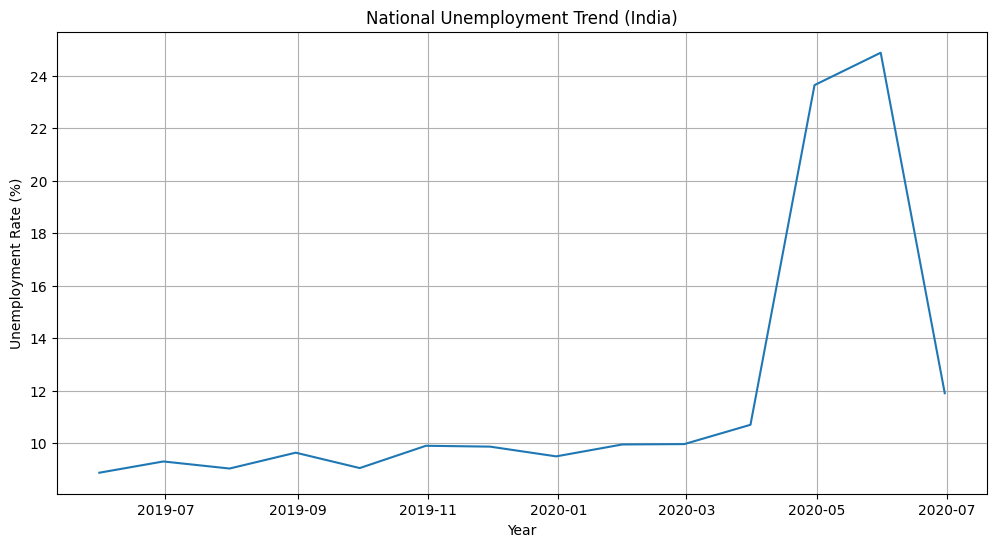

In [23]:
plt.figure(figsize=(12,6))
plt.plot(national_trend.index, national_trend.values)
plt.title("National Unemployment Trend (India)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid()
plt.show()


In [24]:
covid_start = "2020-03-01"

pre_covid = national_trend[national_trend.index < covid_start]
post_covid = national_trend[national_trend.index >= covid_start]

print("Pre-covid Average:", pre_covid.mean())
print("Post-covid Average:", post_covid.mean())

Pre-covid Average: 9.508323969496612
Post-covid Average: 17.78025991704374


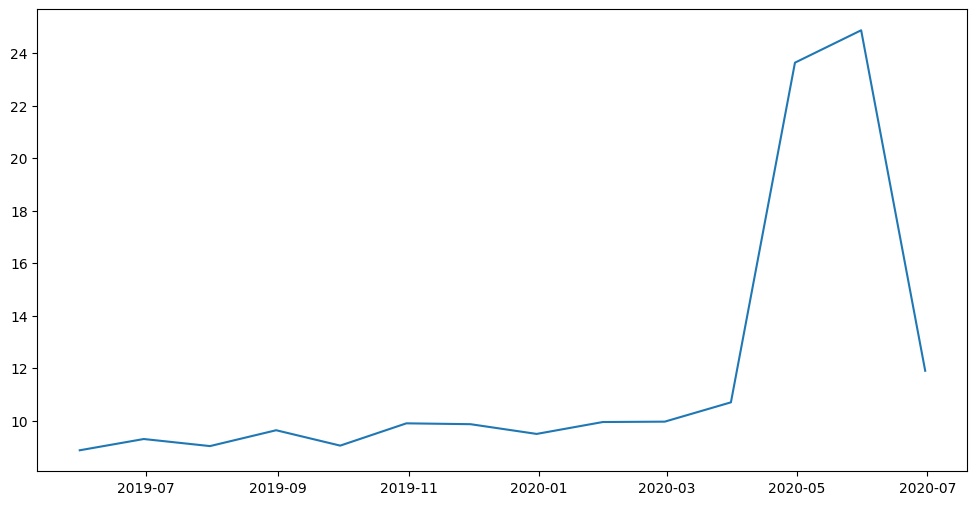

In [25]:
plt.figure(figsize=(12,6))
plt.plot(national_trend.index, national_trend.values)

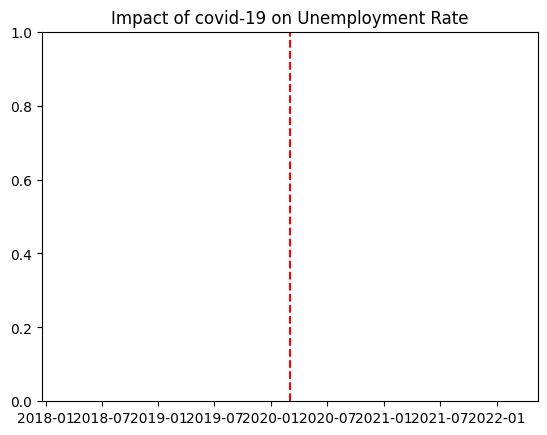

In [26]:
plt.axvline(pd.to_datetime(covid_start), color='red', linestyle='--')
plt.title("Impact of covid-19 on Unemployment Rate")
plt.show()

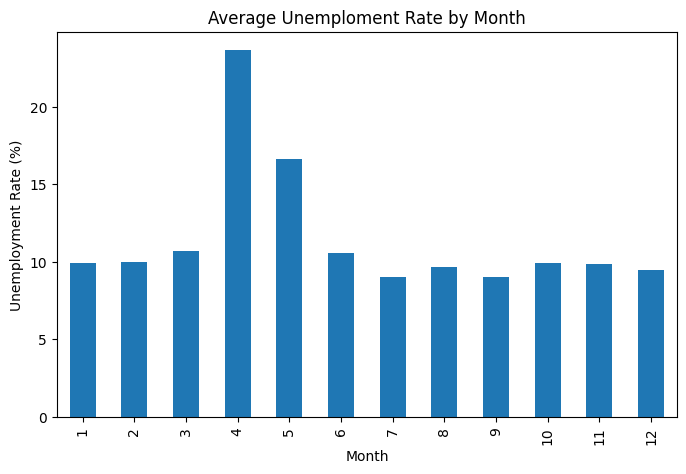

In [27]:
#seasonal trend analysis

df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(kind='bar')
plt.title("Average Unemploment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.show()

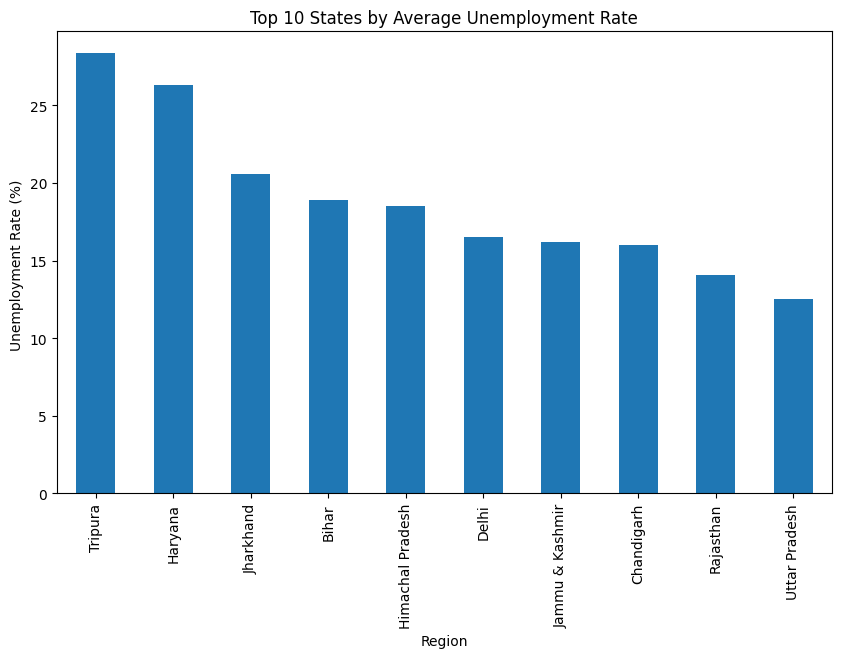

In [29]:
#state wise comparison

state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top_states = state_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title("Top 10 States by Average Unemployment Rate")
plt.ylabel("Unemployment Rate (%) ")
plt.show()

In [30]:
#statistical significance test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(pre_covid, post_covid)

print("T_statistic:", t_stat)
print("P-value:", p_value)

T_statistic: -3.7046719474954055
P-value: 0.0030099653630617797
